<a href="https://colab.research.google.com/github/shehzadtm/KhuramFiles/blob/main/SPYTrade_Analysis_Improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPY candidate screener: trend plus liquidity confirmation

This Colab notebook scans SPY constituents and produces a shortlist for **research**.
It does not place trades or issue buy/sell advice.

Workflow: load constituents → download SPY and every stock **once** → identify a
20/50-day moving-average trend → confirm that price strength is supported by volume,
dollar volume, price-volume trend, and relative performance versus SPY.

In [1]:
# Run once in Colab. pandas_ta is intentionally not needed.
!pip -q install yfinance openpyxl xlsxwriter

from google.colab import drive
drive.mount('/content/drive')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 4.4 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Change only these settings.
CONSTITUENTS_FILE = '/content/drive/MyDrive/StockAnalysis/SPY_ETF-06-01-2026.xlsx'
HISTORY_PERIOD = '1y'       # Enough history for the 50-day measures
TOP_N = 30

# Conservative review thresholds, not trading instructions.
MIN_DOLLAR_VOLUME_RATIO = 0.90   # latest 20 days vs. preceding 20 days

RUN_TIMESTAMP_UTC = pd.Timestamp.now(tz='UTC').strftime('%Y%m%d_%H%M%SZ')
OUTPUT_FILE = f'/content/drive/MyDrive/StockAnalysis/SPY_candidate_screen_{RUN_TIMESTAMP_UTC}.xlsx'


In [3]:
def yahoo_symbol(value):
    # Convert BRK.B-style symbols to Yahoo Finance's BRK-B convention.
    return str(value).strip().upper().replace('.', '-')


def load_constituents(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Constituent file not found: {path}')
    constituents = pd.read_excel(path)
    column = next((c for c in ('Identifier', 'Symbol', 'Ticker') if c in constituents.columns), None)
    if column is None:
        raise ValueError('The Excel file needs an Identifier, Symbol, or Ticker column.')
    symbols = [yahoo_symbol(value) for value in constituents[column].dropna()]
    return list(dict.fromkeys(symbol for symbol in symbols if symbol and symbol != '-'))


def download_universe_once(symbols, period):
    # The notebook's only market-data download; every later cell uses this cache.
    requested = list(dict.fromkeys(['SPY', *symbols]))
    raw = yf.download(
        tickers=requested,
        period=period,
        group_by='ticker',
        auto_adjust=True,
        progress=False,
        threads=True,
    )
    if raw.empty:
        raise RuntimeError('Yahoo Finance returned no data. Try again later.')

    cache = {}
    for symbol in requested:
        try:
            if isinstance(raw.columns, pd.MultiIndex):
                if symbol in raw.columns.get_level_values(0):
                    frame = raw[symbol].copy()
                elif symbol in raw.columns.get_level_values(1):
                    frame = raw.xs(symbol, axis=1, level=1).copy()
                else:
                    continue
            else:
                frame = raw.copy() if len(requested) == 1 else pd.DataFrame()
            if {'Close', 'Volume'}.issubset(frame.columns):
                frame = frame.dropna(subset=['Close', 'Volume'])
                if not frame.empty:
                    cache[symbol] = frame
        except (KeyError, TypeError):
            pass
    return cache


symbols = load_constituents(CONSTITUENTS_FILE)
market_data = download_universe_once(symbols, HISTORY_PERIOD)
missing_symbols = sorted(set(symbols) - set(market_data))

print(f'Cached {len(market_data) - ("SPY" in market_data)} SPY stocks plus SPY.')
print(f'Unavailable symbols: {len(missing_symbols)}')
if 'SPY' not in market_data:
    raise RuntimeError('SPY benchmark data was unavailable.')


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: SATS"}}}
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: 2602335D"}}}
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['SATS', '2602335D']: YFPricesMissingError('possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")')


Cached 502 SPY stocks plus SPY.
Unavailable symbols: 2


In [4]:
SHORT, LONG = 20, 50

def pct_return(series, days):
    if len(series) <= days or series.iloc[-days - 1] == 0:
        return np.nan
    return 100 * (series.iloc[-1] / series.iloc[-days - 1] - 1)


def ratio_current_to_prior(series, days):
    if len(series) < 2 * days:
        return np.nan
    prior = series.iloc[-2 * days:-days].mean()
    return np.nan if prior == 0 else series.iloc[-days:].mean() / prior


def signed_volume_ratio(close, volume, days):
    # Positive means more volume occurred on up days than down days.
    recent_volume = volume.iloc[-days:]
    if recent_volume.sum() == 0:
        return np.nan
    direction = np.sign(close.pct_change().iloc[-days:]).fillna(0)
    return (direction * recent_volume).sum() / recent_volume.sum()


def pvt_change(close, volume, days):
    # Price-volume trend change; positive values support accumulation.
    pvt = (close.pct_change().fillna(0) * volume).cumsum()
    if len(pvt) <= days:
        return np.nan
    baseline = max(abs(pvt.iloc[-days - 1]), 1.0)
    return 100 * (pvt.iloc[-1] - pvt.iloc[-days - 1]) / baseline


spy_close = market_data['SPY']['Close'].astype(float)
spy_return_20 = pct_return(spy_close, SHORT)
spy_return_50 = pct_return(spy_close, LONG)


In [5]:
rows = []
for symbol in symbols:
    frame = market_data.get(symbol)
    if frame is None or len(frame) < LONG + 1:
        continue
    close = frame['Close'].astype(float)
    volume = frame['Volume'].astype(float)
    dollar_volume = close * volume
    sma20 = close.rolling(SHORT).mean().iloc[-1]
    sma50 = close.rolling(LONG).mean().iloc[-1]
    ret20, ret50 = pct_return(close, SHORT), pct_return(close, LONG)
    signed20 = signed_volume_ratio(close, volume, SHORT)
    signed50 = signed_volume_ratio(close, volume, LONG)
    dollar_volume_ratio = ratio_current_to_prior(dollar_volume, SHORT)
    pvt20, pvt50 = pvt_change(close, volume, SHORT), pvt_change(close, volume, LONG)

    trend_ok = close.iloc[-1] > sma20 > sma50
    flow_ok = (
        dollar_volume_ratio >= MIN_DOLLAR_VOLUME_RATIO
        and signed20 > 0 and signed50 > 0
        and pvt20 > 0 and pvt50 > 0
    )
    outperforming = ret20 > spy_return_20 and ret50 > spy_return_50
    score = int(trend_ok) + int(flow_ok) + int(outperforming)
    status = 'Research candidate' if score == 3 else 'Watch' if score == 2 else 'Not confirmed'

    rows.append({
        'Symbol': symbol,
        'Data_As_Of': close.index[-1].strftime('%Y-%m-%d'),
        'Run_UTC': RUN_TIMESTAMP_UTC,
        'Status': status,
        'Confirmation_Score_0_to_3': score,
        'Last_Price': close.iloc[-1],
        'Return_20D_%': ret20,
        'Return_50D_%': ret50,
        'Vs_SPY_20D_pp': ret20 - spy_return_20,
        'Vs_SPY_50D_pp': ret50 - spy_return_50,
        'Above_SMA20': close.iloc[-1] > sma20,
        'SMA20_Above_SMA50': sma20 > sma50,
        'Dollar_Volume_20vPrior20_Ratio': dollar_volume_ratio,
        'Signed_Volume_20D': signed20,
        'Signed_Volume_50D': signed50,
        'PVT_20D_Change_%': pvt20,
        'PVT_50D_Change_%': pvt50,
    })

screen = pd.DataFrame(rows)
screen = screen.sort_values(
    ['Confirmation_Score_0_to_3', 'Vs_SPY_20D_pp', 'Dollar_Volume_20vPrior20_Ratio'],
    ascending=[False, False, False],
).reset_index(drop=True)

numeric_columns = screen.select_dtypes(include='number').columns
screen[numeric_columns] = screen[numeric_columns].round(2)
shortlist = screen.query("Status == 'Research candidate'").head(TOP_N)

print(f'SPY return: {spy_return_20:.2f}% over 20 days; {spy_return_50:.2f}% over 50 days')
display(shortlist)


SPY return: 1.24% over 20 days; 2.72% over 50 days


,Symbol,Data_As_Of,Run_UTC,Status,Confirmation_Score_0_to_3,Last_Price,Return_20D_%,Return_50D_%,Vs_SPY_20D_pp,Vs_SPY_50D_pp,Above_SMA20,SMA20_Above_SMA50,Dollar_Volume_20vPrior20_Ratio,Signed_Volume_20D,Signed_Volume_50D,PVT_20D_Change_%,PVT_50D_Change_%
0,MRNA,2026-08-31,20260901_030444Z,Research candidate,3,140.34,154.52,119.42,153.28,116.70,True,True,12.71,0.25,0.21,1177.91,1222.90
1,PLTR,2026-08-31,20260901_030444Z,Research candidate,3,186.38,48.33,45.08,47.09,42.36,True,True,1.64,0.22,0.15,383.10,353.35
2,VEEV,2026-08-31,20260901_030444Z,Research candidate,3,285.69,40.20,84.49,38.96,81.77,True,True,1.63,0.61,0.44,328.51,168.52
3,CRM,2026-08-31,20260901_030444Z,Research candidate,3,257.54,38.50,69.68,37.26,66.96,True,True,1.54,0.32,0.17,979.89,339.83
4,PSKY,2026-08-31,20260901_030444Z,Research candidate,3,10.91,37.06,9.32,35.82,6.60,True,True,1.17,0.87,0.21,17.58,6.51
5,NEM,2026-08-31,20260901_030444Z,Research candidate,3,126.06,34.52,19.30,33.28,16.58,True,True,1.46,0.43,0.01,167.45,518.97
6,IT,2026-08-31,20260901_030444Z,Research candidate,3,198.11,31.18,48.31,29.94,45.59,True,True,1.56,0.28,0.11,48.00,49.10
7,SMCI,2026-08-31,20260901_030444Z,Research candidate,3,37.28,30.17,21.59,28.93,18.87,True,True,1.63,0.35,0.11,6774.85,219.98
8,NOW,2026-08-31,20260901_030444Z,Research candidate,3,147.99,29.60,55.71,28.36,52.99,True,True,0.90,0.40,0.20,70.88,80.89
9,COIN,2026-08-31,20260901_030444Z,Research candidate,3,188.12,28.41,15.23,27.17,12.51,True,True,1.36,0.28,0.15,568.68,1856.84


Saved report: /content/drive/MyDrive/StockAnalysis/SPY_candidate_screen_20260901_030444Z.xlsx


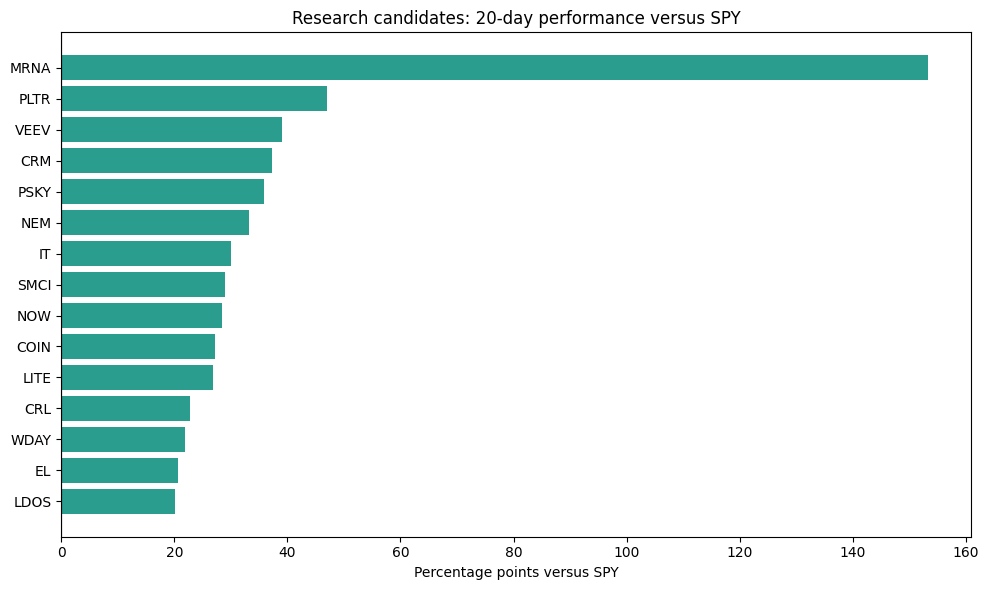

In [6]:
# Save the full screen, shortlist, and unavailable symbols to one Excel workbook.
with pd.ExcelWriter(OUTPUT_FILE, engine='xlsxwriter') as writer:
    screen.to_excel(writer, sheet_name='All Results', index=False)
    shortlist.to_excel(writer, sheet_name='Shortlist', index=False)
    pd.DataFrame({'Unavailable Symbol': missing_symbols}).to_excel(
        writer, sheet_name='Unavailable', index=False
    )
    pd.DataFrame([{
        'Run_UTC': RUN_TIMESTAMP_UTC,
        'Latest_SPY_Data_Date': spy_close.index[-1].strftime('%Y-%m-%d'),
        'Constituent_File': CONSTITUENTS_FILE,
        'History_Period': HISTORY_PERIOD,
    }]).to_excel(writer, sheet_name='Run Metadata', index=False)

    for sheet_name, dataframe in {'All Results': screen, 'Shortlist': shortlist}.items():
        worksheet = writer.sheets[sheet_name]
        worksheet.freeze_panes(1, 0)
        worksheet.autofilter(0, 0, len(dataframe), len(dataframe.columns) - 1)
        for column_index, column in enumerate(dataframe.columns):
            worksheet.set_column(column_index, column_index, min(max(len(column) + 2, 14), 34))

print(f'Saved report: {OUTPUT_FILE}')

# A quick visual check: stocks with the best 20-day relative performance.
plot_data = shortlist.head(15).sort_values('Vs_SPY_20D_pp')
if not plot_data.empty:
    plt.figure(figsize=(10, 6))
    plt.barh(plot_data['Symbol'], plot_data['Vs_SPY_20D_pp'], color='#2a9d8f')
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title('Research candidates: 20-day performance versus SPY')
    plt.xlabel('Percentage points versus SPY')
    plt.tight_layout()
    plt.show()
